![Header Lab 2](https://su2.utia.cas.cz/files/labs/23-205/header__lab5a.png)

In this lab, we focus on more advanced deep learning topics, including Vision Transformers and generative models. Participants will have an opportunity to delve into Generative Adversarial Networks (GANs) and diffusion models, exploring how these powerful techniques can be used to generate new data that is similar to the input data.

**Course website:** [su2.utia.cas.cz/labs.html](https://su2.utia.cas.cz/labs.html)

## Schedule
Lab 0 – Introduction to Python and Basic Machine Learning

Lab 1 – Fundamentals of Deep Learning with PyTorch

Lab 2 – Image Classification and Transfer Learning

Lab 3 – Image Processing with Deep Learning

Lab 4 – Sequence Models and NLP

*Lab 5 – Advanced Vision and Generative Models*

Lab 6 – Project Presentation

**Attendance:**

Absences are limited to 20% of the total sessions, i.e., only one lab from Labs 1-5 can be missed.  Attendance for Lab 6, the Project Presentation, is mandatory for all students who wish to pass the course.
<br /><br />





## Final assessment and class competition

<img src="https://su2.utia.cas.cz/files/labs/23-205/dwarf2.png" width="400px">

<strong>Instruction, evaluation and other info:</strong>
<a href="https://su2.utia.cas.cz/labs.html#projects">https://su2.utia.cas.cz/labs.html#projects</a>

<strong>Presentation Guidelines::</strong>
<a href="https://su2.utia.cas.cz/labs.html#lab6">https://su2.utia.cas.cz/labs.html#lab6</a>


                       

# Part 1: Vision Transformer

In this part, we continue our exploration of Transformer models, now applying them to image processing. We begin by examining the pioneering work of [Alexey Dosovitskiy et al.](https://openreview.net/pdf?id=YicbFdNTTy) in employing Transformers for image recognition. This leads us to an intriguing inquiry: Have ConvNets, the long-standing standard in computer vision, been surpassed by a newer, more effective architecture?

[Figure credit to Phil Wang](https://github.com/lucidrains/vit-pytorch/blob/main/images/vit.gif), [source tutorial by Phillip Lippe](https://uvadlc-notebooks.readthedocs.io/en/latest/index.html), and [model zoo here](https://pytorch.org/vision/main/models.html#).
<br />

<img src="https://su2.utia.cas.cz/files/labs/23-205/vit.gif" width="700px">


In [15]:
# @title Imports and Helper Functions
%%capture
!pip install lightning

import os
import numpy as np
import random
import math
import json
from functools import partial
from PIL import Image
import pytorch_lightning as pl
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb
import matplotlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
pl.seed_everything(42)
import requests
import zipfile
import errno
from lightning.pytorch.loggers import CSVLogger, WandbLogger
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

filename = 'ViT.zip'
localfile = filename
url = 'https://su2.utia.cas.cz/files/labs/23-205/{}'

r = requests.get(url.format(filename), allow_redirects=True, verify=False)  # <- verify=False
open(localfile, 'wb').write(r.content)

with zipfile.ZipFile(localfile, 'r') as zip_ref:
    zip_ref.extractall("")

# filename = 'ViT.zip'
# try:
#     localfile = f'{filename}'
#     url = 'https://su2.utia.cas.cz/files/labs/23-205/{}'
#     r = requests.get(url.format(filename), allow_redirects=True)
#     open(localfile, 'wb').write(r.content)
#     with zipfile.ZipFile(localfile, 'r') as zip_ref:
#         zip_ref.extractall("")
# except OSError as e:
#     if e.errno != errno.EEXIST:
#         raise
#     else:
#         print(f'{filename[:-4]} folder already exists!')

INFO:lightning_fabric.utilities.seed:Seed set to 42


## The CIFAR-10 dataset


<img src="https://su2.utia.cas.cz/files/labs/23-205/cifar10.png" width="700px">

The `transforms.Normalize` constants scale and shift data to zero mean and unit standard deviation.

In [16]:
DATASET_PATH = "../data"
test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])

# training augmentation
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32),scale=(0.8,1.0),ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=train_transform, download=True)
val_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=test_transform, download=True)
pl.seed_everything(42)
train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
pl.seed_everything(42) # to exclude augmentation from the validation set
_, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])
test_set = CIFAR10(root=DATASET_PATH, train=False, transform=test_transform, download=True)

train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Input words to the Vision Transformer are patches $M\times M$. Image $N\times  N$ must be therfore split into $(N/M)^2$ patches.
<img src="https://su2.utia.cas.cz/files/labs/23-205/patches.png" width="700px">

In [17]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H//patch_size, patch_size, W//patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5) # [B, H', W', C, p_H, p_W]
    x = x.flatten(1,2)              # [B, H'*W', C, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2,4)          # [B, H'*W', C*p_H*p_W]
    return x

**Visualize some examples from CIFAR-10**

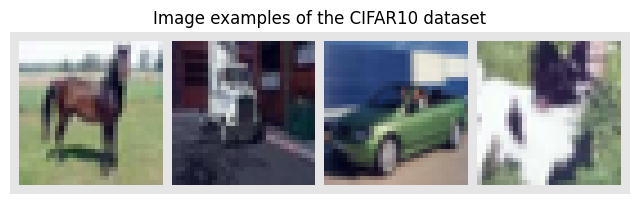

In [18]:
NUM_IMAGES = 4
CIFAR_images = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(CIFAR_images, nrow=4, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the CIFAR10 dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

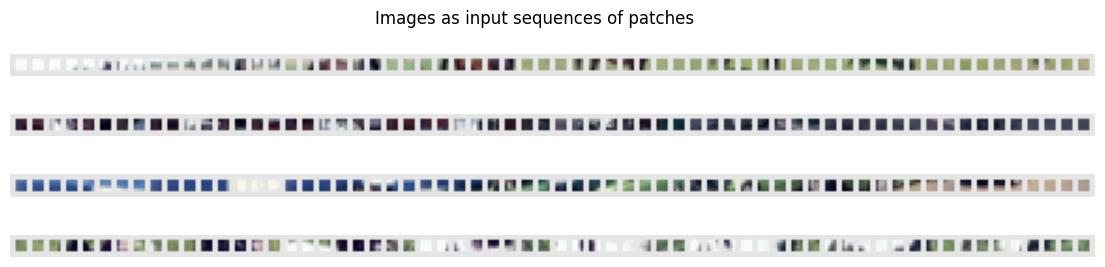

In [19]:
img_patches = img_to_patch(CIFAR_images, patch_size=4, flatten_channels=False)

fig, ax = plt.subplots(CIFAR_images.shape[0], 1, figsize=(14,3))
fig.suptitle("Images as input sequences of patches")
for i in range(CIFAR_images.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=64, normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis('off')
plt.show()
plt.close()

Unlike the initial images, recognizing the objects from these lists of patches is now significantly more challenging (for human). However, these patch lists are what we use as input for the Transformer in image classification tasks. The model must independently understand how to merge these patches to identify the objects.
**The inductive bias in CNNs that an image is a grid of pixels, is lost in this input format.**

## ViT model
We implement Pre-Layer Normalization at the start of residual blocks, rather than between them, facilitating improved gradient flow and eliminating the requirement for a warm-up phase.

[Layer Norm vs. Batch Norm](https://su2.utia.cas.cz/files/labs/23-205/LN.jpg)

[GELU vs ReLU](https://su2.utia.cas.cz/files/labs/23-205/gelu.png)

If the embedding dimension is 256, using 8 heads in MHA, each head's feature space dimension is $\frac{256}{8} = 32.$


In [20]:
class TransformerEncoderBlock(nn.Module):

    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors (e.g. 256)
            hidden_dim - Dimensionality of hidden layer in feed-forward network (e.g. 512)
                         (usually 2-4x larger than embed_dim)
            num_heads - Number of heads to use in the Multi-Head Attention block (e.g. 8)
            dropout - Amount of dropout to apply in the feed-forward network (e.g. 0.2)
        """
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                          dropout=dropout)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(), # 👈
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )


    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0] # 👈 (Q, K, V)
        x = x + self.linear(self.layer_norm_2(x))
        return x

<img src="https://su2.utia.cas.cz/files/labs/23-205/encoder2.png" width="700px">


In [21]:
class VisionTransformer(nn.Module):

    def __init__(self, embed_dim, hidden_dim, num_channels, num_heads, num_layers, num_classes, patch_size, num_patches, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of the input feature vectors to the Transformer (e.g. 256)
            hidden_dim - Dimensionality of the hidden layer in the feed-forward networks (e.g. 512)
                         within the Transformer
            num_channels - Number of channels of the input (3 for RGB)
            num_heads - Number of heads to use in the Multi-Head Attention block (e.g. 8)
            num_layers - Number of layers to use in the Transformer (e.g. 6)
            num_classes - Number of classes to predict (e.g. 10)
            patch_size - Number of pixels that the patches have per dimension (e.g. 4)
            num_patches - Maximum number of patches an image can have (e.g. 64)
            dropout - Amount of dropout to apply in the feed-forward network and (e.g. 0.2)
                      on the input encoding
        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels*(patch_size**2), embed_dim)
        self.transformer = nn.Sequential(*[TransformerEncoderBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1,1+num_patches,embed_dim))


    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embedding[:,:T+1]

        # Apply Transformer
        x = self.dropout(x)
        x = x.transpose(0, 1) # 👈
        x = self.transformer(x)

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

<img src="https://su2.utia.cas.cz/files/labs/23-205/encoder2.png" width="700px">

The model implemented a linear projection layer mapping input patches to a larger feature vector, a classification token (CLS token) for prediction, learnable positional encodings for sequence conversion, and an MLP head that processes the CLS token's feature vector for classification prediction.

## ✍🏼 Excercise 1

Based on your knowledge from previous exercises, finish writting the ViT module according to the instructions in the code.

❗Important to complete to continue in this exercise.❗

In [22]:
class ViT(pl.LightningModule):
    def __init__(self, model_kwargs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(**model_kwargs)
        self.loss_fn = F.cross_entropy
        self.learning_rate = lr

    def forward(self, x):
        return self.model(x)


    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.learning_rate)
        lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [lr_scheduler]

    def _calculate_loss(self, batch, mode="train"):
        imgs, labels = batch
        preds = self.forward(imgs)
        loss = self.loss_fn(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        self.log(f"{mode}_loss", loss)
        self.log(f"{mode}_acc", acc)
        return loss

    def training_step(self, batch, batch_idx):
        return self._calculate_loss(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._calculate_loss(batch, "val")

    def test_step(self, batch, batch_idx):
        self._calculate_loss(batch, "test")

## Training
⚠️ We now load pretrained model parameters to save time. Feel free to train it from scratch.

In [23]:
pl.seed_everything(42)  # For reproducibility
model = ViT(model_kwargs={
                            'embed_dim': 256,
                            'hidden_dim': 512,
                            'num_heads': 8,
                            'num_layers': 6,
                            'patch_size': 4,
                            'num_channels': 3,
                            'num_patches': 64,
                            'num_classes': 10,
                            'dropout': 0.2
                        },
                        lr=3e-4)

# PyTorch Lightning Trainer
logger = CSVLogger("logs", name="ViT")
ngpus = torch.cuda.device_count() if torch.cuda.is_available() else 1
trainer = pl.Trainer(logger=logger, devices=ngpus, accelerator="gpu" if ngpus > 0 else None, max_epochs=180)

# trainer.fit(model, train_loader, val_loader)
model = ViT.load_from_checkpoint('ViT.ckpt')

val_result = trainer.test(model, val_loader, verbose=False)
test_result = trainer.test(model, test_loader, verbose=False)
print(test_result)
results = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

print("ViT results", results)

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.6.4 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ViT.ckpt`
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[{'test_loss': 1.2494336366653442, 'test_acc': 0.7713000178337097}]
ViT results {'test': 0.7713000178337097, 'val': 0.7781999707221985}


## ✍🏼 Excercise 2 (voluntary)

Following the release of vision transformers, the field of computer vision experienced a surge of innovations and developments, leading to various new models. Let's explore some notable examples:

> **[DeiT (Data-efficient Image Transformers)](https://arxiv.org/pdf/2012.12877.pdf)**

> **[Swin Transformer](https://openaccess.thecvf.com/content/ICCV2021/papers/Liu_Swin_Transformer_Hierarchical_Vision_Transformer_Using_Shifted_Windows_ICCV_2021_paper.pdf)**

> **[MAE (Masked Autoencoder)](https://arxiv.org/pdf/2111.06377.pdf)**

> **[ConvNeXt/ResNeXt](https://arxiv.org/pdf/2201.03545.pdf)**

> **[CLIP: Connecting text and images](https://arxiv.org/pdf/2103.00020.pdf)**

> **[DETR: End-to-End Object Detection with Transformers](https://arxiv.org/pdf/2005.12872.pdf)**

Your exercise is to select **one** of these papers and read it. Afterward, write a paragraph summarizing the main contributions of the paper, discussing its strengths, and evaluating its impact in the field of computer vision.

`[your paragraph]`

# Part 2: Generative adversial networks




Generative Adversarial Networks (GANs) are a groundbreaking concept in machine learning, introduced by Ian Goodfellow in 2014. The foundational paper, "[Generative Adversarial Nets](https://papers.nips.cc/paper/5423-generative-adversarial-nets.pdf)," laid the groundwork for this technology. GANs are designed with a dual-model architecture, consisting of a generator and a discriminator. Their primary objective is to enable a deep learning model to learn and replicate the distribution of training data. This capability allows GANs to produce new, synthetic data that closely resembles the original training set.

<img src="https://su2.utia.cas.cz/files/labs/23-205/gan4.png">

Throughout the training process, the generator continually strives to outsmart the discriminator by producing increasingly convincing fakes. Simultaneously, the discriminator works to improve its ability to distinguish between real and fake images accurately. The equilibrium in this dynamic is reached when the generator produces perfect forgeries indistinguishable from the training data. At this point, the discriminator is left to guess, with only 50% confidence, whether the output from the generator is real or fake.

$z$... latent space vector (sampled from a standard normal distribution)<br />
$G(z)$... generator network (maps the latent vectors to images)<br />
<br />
$x$... image<br />
$D(x)$... discriminator network (output scalar probability)<br />
$\qquad$ HIGH if $x$ is real<br />
$\qquad$ LOW if $x$ comes from generator<br />
<br />
$D(G(z))$ is the probability (scalar) that the output of the
generator $G$ is a real image.
<br /><br />



<img src="https://su2.utia.cas.cz/files/labs/23-205/ggan1.png">

**The GAN loss function is**
<img src="https://su2.utia.cas.cz/files/labs/23-205/ggan2.png">

$D$ tries to maximize the probability it correctly classifies reals [$\max logD(x)$] and fakes [$\max log(1-D(G(z)))$]
<br />
$G$ tries to minimize the probability that
$D$ will predict its outputs are fake [$\min log(1-D(G(z)))$].

<img src="https://su2.utia.cas.cz/files/labs/23-205/dg4.png">

In other words,<br />
$\qquad$ Discriminator wants:<br />
$\qquad$ $\qquad$ $D(x)$ to be close 1 for real images $x$ (maximize ($logD(x)$)<br />
$\qquad$ $\qquad$ $D(G(z))$ to be close 0 for fake images $G(z)$ (maximize ($log(1-D(G(z)))$)
<br />
$\qquad$ Generator wants:<br />
$\qquad$ $\qquad$ $D(G(z))$ to be close 1 for fake images $G(z)$ (minimize ($log(1-D(G(z)))$)


## Problem
Check the website [This Person Does Not Exist](https://thispersondoesnotexist.com/) from 2020.

Each time the page is refreshed, a generative adversarial network (GAN) (originally coded by Nvidia) renders hyper-realistic portraits of completely fake people.

Let us use deep convolutional GAN for mastering this task, ie. generating new faces (kind of).

<img src="https://su2.utia.cas.cz/files/labs/23-205/gan_res.png">

## Load packages

In [24]:
%cd /content
import argparse
import os
import random
import requests
import zipfile
import errno
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt

/content


## Setup


In [25]:
dataroot = "/content/celeba/"
workers = 2                           # worker threads for loading the data with the DataLoader
batch_size = 128
image_size = 64
nc = 3                                # number of color channels in the input images
nz = 100                              # length of latent vector
ngf = 64                              # relates to the depth of feature maps carried through the generator
ndf = 64                              # the depth of feature maps propagated through the discriminator
num_epochs = 10
lr = 0.0002                           # learning rate for training
beta1 = 0.5                           # hyperparameter for Adam optimizers
manualSeed = 999                      # for reproducibility
random.seed(manualSeed)
torch.manual_seed(manualSeed)

## Data: Prepare and "Split"
We will use the subset of  [Celeb-A Faces dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) with 50000 celebrity images.

<img src="https://su2.utia.cas.cz/files/labs/23-205/celeba.jpg">


In [26]:
# @title


urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

!mkdir -p 'celeba'
%cd 'celeba'

filename = 'img_align_celeba.zip'

try:
    os.mkdir(f'{filename[:-4]}')

    localfile = filename
    url = 'https://su2.utia.cas.cz/files/labs/23-205/{}'

    r = requests.get(url.format(filename), allow_redirects=True, verify=False)
    with open(localfile, 'wb') as f:
        f.write(r.content)

    with zipfile.ZipFile(localfile, 'r') as zip_ref:
        zip_ref.extractall("")
except OSError as e:
    if e.errno != errno.EEXIST:
        raise
    else:
        print(f'{filename[:-4]} folder already exists!')


/content/celeba


<img src="https://su2.utia.cas.cz/files/labs/23-205/files2.png">

**Set dataset size**
<a name="cell-id"></a>

In [27]:
set_dataset_len = 5000

**Create Pytorch dataset**

In [28]:
# Create the dataset
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))
dataset = torch.utils.data.random_split(dataset, [set_dataset_len, len(dataset)-set_dataset_len])[0]

# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Plot some training images**

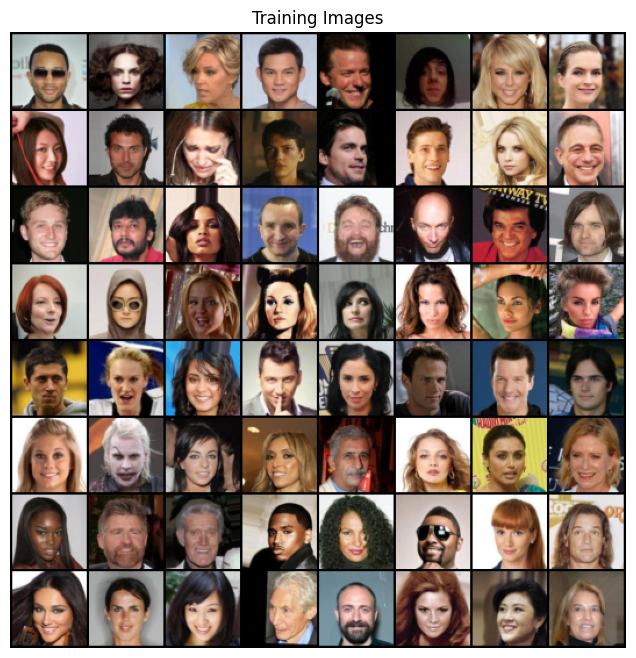

In [31]:
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))

## Model: Design and Train

Let us initialize model weights according to the paper [DCGAN](https://arxiv.org/pdf/1511.06434.pdf).

In [32]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

**Model Generator**

Recall, the generator, $G$, is designed to map the latent space vector
($z$) to data-space (image space).

A sketch of the generator from the [DCGAN](https://arxiv.org/pdf/1511.06434.pdf) paper is shown below.

<img src="https://su2.utia.cas.cz/files/labs/23-205/dcgan_generator.png">

In [33]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

# Create the generator
netG = Generator().to(device)

# Apply the weights_init function to randomly initialize all weights
#  to mean=0, stdev=0.2.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


**Transposed convolution**
  
  Instead of sliding the kernel over the input and performing element-wise multiplication and summation, a transposed convolutional layer slides the input over the kernel and performs element-wise multiplication and summation. This results in an output that is larger than the input, and the size of the output can be controlled by the stride and padding parameters of the layer.

[See more about transposed convolution](https://www.geeksforgeeks.org/machine-learning/what-is-transposed-convolutional-layer/)

**Model Discriminator**

In [34]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Create the Discriminator
netD = Discriminator().to(device)

# Apply the weights_init function to randomly initialize all weights
#  to mean=0, stdev=0.2.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


**Loss function and optimizers**

<img src="https://su2.utia.cas.cz/files/labs/23-205/dg4.png">
<img src="https://su2.utia.cas.cz/files/labs/23-205/ggan2.png">

Let us simplify the GAN loss described at the beginning of this Part by using the Binary Cross
Entropy loss
([BCELoss](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss))
function defined in PyTorch as:
<br /><br />
\begin{align}\ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad l_n = - \left[ y_n \cdot \log x_n + (1 - y_n) \cdot \log (1 - x_n) \right]\end{align}
<br />

Notice how this function provides the calculation of both log components
in the objective function (i.e. $log(D(x))$ and
$log(1-D(G(z)))$).
<br />

$\qquad$For real images (label $y_n=1$), only the first term will be used.

$\qquad$For fake images (label $y_n=0$), only the second term will be applied.

As specified in the [DCGAN](https://arxiv.org/pdf/1511.06434.pdf) paper, let us setup both optimizers as follows: Adam  with learning rate 0.0002 and Beta1 = 0.5.

In [35]:
# Initialize BCELoss function
criterion = nn.BCELoss()

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

In [ ]:
real_batch = next(iter(dataloader))
netD.zero_grad()
output = netD(real_batch[0].to(device))
print(real_batch[0].size())
print(output.size())

**Training**

Training GANs is somewhat of an art form, as incorrect hyperparameter settings lead to mode collapse with little explanation of what went wrong.

[Tips and tricks to make GANs work](https://github.com/soumith/ganhacks).


Let us use two tricks:
1. for Discriminator, separate calculation for real and fake images:
    * minimize loss $-log(x_n)$ for real samples $(y_n = 1)$
    * minimize loss $-log(1-x_n)$ for fake samples $(y_n = 0)$

2.  for Generator, its objective is to fool the discriminator by minimizing the loss $-log(x_n)$ pretending that fake samples are real $(y_n = 1)$

<br />

$l_n = - \left[ y_n \cdot \log x_n + (1 - y_n) \cdot \log (1 - x_n) \right]$
<br /><br />

<img src="https://su2.utia.cas.cz/files/labs/23-205/mlog.png" width="400px">





**Let us train now!** (10 epochs, 5K images, wait 3 min)

In [36]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: minimize -log(D(x)) - log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        real_on_device = data[0].to(device)
        b_size = real_on_device.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_on_device).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)                  # minimize -log(D(x))
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)                  # minimize  -log(1 - D(G(z)))
        # Calculate the gradients for this batch
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: minimize -log(D(G(z))) as real
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)                       # minimize -log(D(G(z))) when fake=real
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/10][0/40]	Loss_D: 1.6486	Loss_G: 5.1228	D(x): 0.5518	D(G(z)): 0.5501 / 0.0098
[1/10][0/40]	Loss_D: 0.1052	Loss_G: 22.5793	D(x): 0.9458	D(G(z)): 0.0000 / 0.0000
[2/10][0/40]	Loss_D: 0.1963	Loss_G: 12.9072	D(x): 0.9061	D(G(z)): 0.0001 / 0.0001
[3/10][0/40]	Loss_D: 0.7189	Loss_G: 5.3426	D(x): 0.9670	D(G(z)): 0.3636 / 0.0200
[4/10][0/40]	Loss_D: 0.8643	Loss_G: 3.3776	D(x): 0.5822	D(G(z)): 0.0419 / 0.1116
[5/10][0/40]	Loss_D: 0.6170	Loss_G: 7.1072	D(x): 0.7367	D(G(z)): 0.0525 / 0.0063
[6/10][0/40]	Loss_D: 1.0245	Loss_G: 4.2631	D(x): 0.5143	D(G(z)): 0.0362 / 0.0418
[7/10][0/40]	Loss_D: 1.8236	Loss_G: 7.6660	D(x): 0.9919	D(G(z)): 0.7081 / 0.0018
[8/10][0/40]	Loss_D: 1.3305	Loss_G: 6.7649	D(x): 0.9702	D(G(z)): 0.6332 / 0.0039
[9/10][0/40]	Loss_D: 0.6067	Loss_G: 5.7415	D(x): 0.9281	D(G(z)): 0.3686 / 0.0070


## Prediction: Make and Evaluate

See how D and G’s losses changed during training.

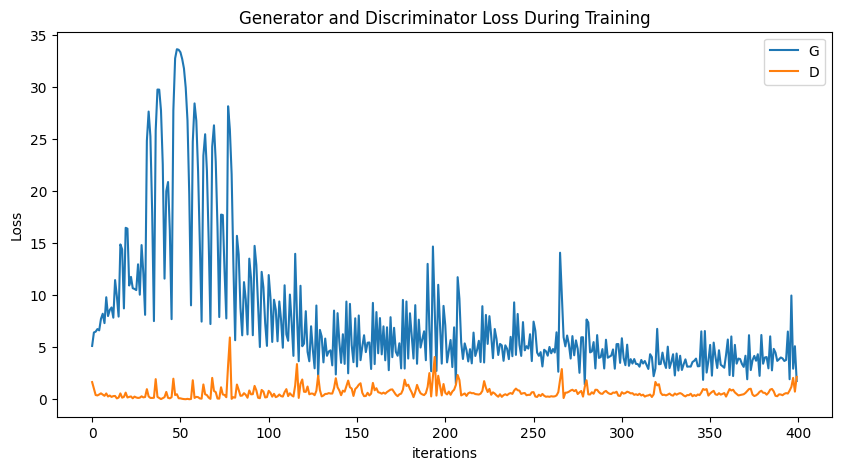

In [37]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

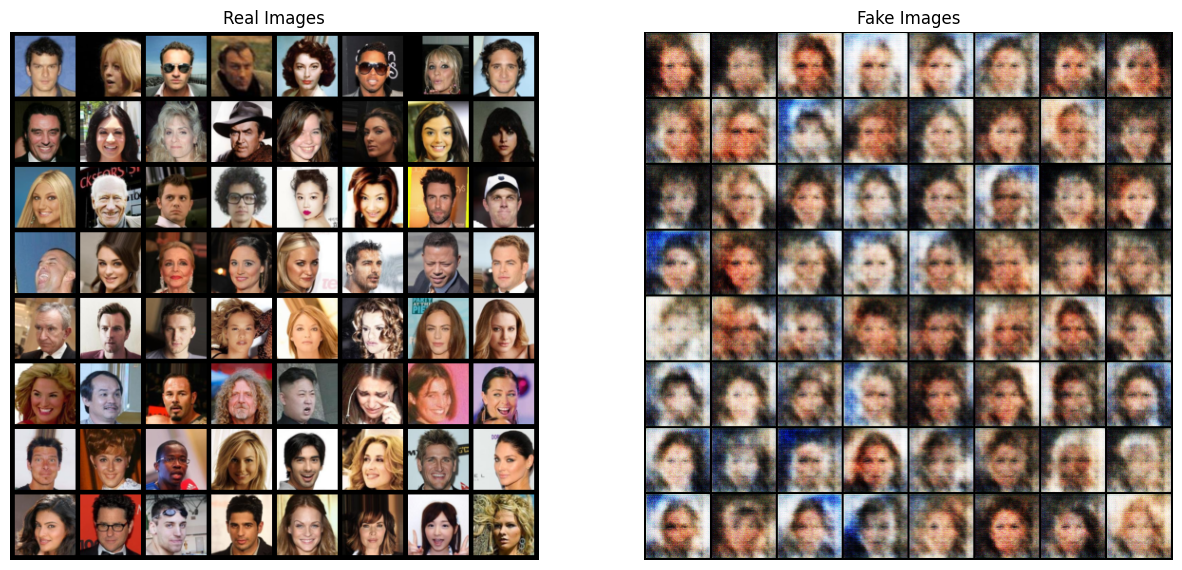

In [38]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

It looks like we are getting something resembling faces, right?

🎯 And now try the whole dataset 50K images ([change here](#cell-id)). Also you can train for longer time to see how good the results get.


## ✍🏼 Excercise 3


In this exercise you will **reuse the DCGAN from above** and train it on a
*different dataset* loaded directly from `torchvision.datasets`.

You can choose for example:

- `"fashion-mnist"` – clothes, shoes, bags (grayscale, but we convert to RGB)
- `"mnist"` – handwritten digits
- `"cifar10"` – small color images (airplanes, cars, cats, dogs, …)
- `"svhn"` – street view house numbers

and only keep a subset of the same class (f.e. only airplanes from cifar10) or choose any other dataset that you find interesting. To get the above mentioned datasets from torchvision use:
```python
from torchvision import datasets

# example: FashionMNIST
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,   # define your own transforms above
)
```

**Important constraints (so it runs quickly in class):**

- Use only a **small subset** of the dataset (e.g. 2 000–5 000 images).
- Train for only **a few epochs** .
- Reuse the **same DCGAN architecture** as for faces.

Your goals:

1. Load and visualize a batch of images from the chosen dataset.
2. Train the GAN on this dataset subset.
3. Generate and show a grid of fake images from your trained generator.
4. Add 2–3 sentences commenting on what dataset you chose, how many images and epochs you used for training and describe your losses during training.



100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]

Number of MNIST training images: 60000
Device: cuda


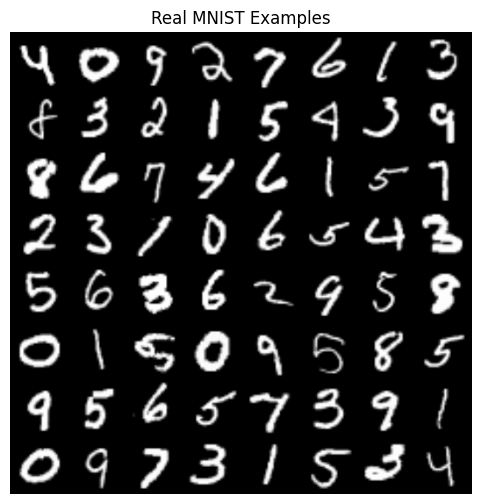

Epoch [1/10]  Loss_D: 0.1950  Loss_G: 3.9203
Epoch [2/10]  Loss_D: 0.5395  Loss_G: 1.8423
Epoch [3/10]  Loss_D: 0.3957  Loss_G: 2.2073
Epoch [4/10]  Loss_D: 0.9208  Loss_G: 0.5093
Epoch [5/10]  Loss_D: 0.7856  Loss_G: 5.7997
Epoch [6/10]  Loss_D: 0.2857  Loss_G: 3.1543
Epoch [7/10]  Loss_D: 0.1308  Loss_G: 3.1283
Epoch [8/10]  Loss_D: 0.2669  Loss_G: 3.2683
Epoch [9/10]  Loss_D: 0.6270  Loss_G: 2.3369
Epoch [10/10]  Loss_D: 0.4562  Loss_G: 3.0826


AttributeError: module 'matplotlib.pyplot' has no attribute 'figur'

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare MNIST dataset
image_size = 64
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])


mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

batch_size = 128
mnist_dataloader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Number of MNIST training images:", len(mnist_train))
print("Device:", device)

real_batch = next(iter(mnist_dataloader))

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Real MNIST Examples")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0][:64], padding=2, normalize=True),
        (1, 2, 0),
    )
)
plt.show()

netG = Generator().to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0

num_epochs_mnist = 10

for epoch in range(num_epochs_mnist):
    for i, (images, _) in enumerate(mnist_dataloader):
        netD.zero_grad()
        images = images.to(device)
        b_size = images.size(0)

        labels = torch.full((b_size,), real_label, device=device)
        output = netD(images).view(-1)
        lossD_real = criterion(output, labels)
        lossD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        labels.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        lossD_fake = criterion(output, labels)
        lossD_fake.backward()
        optimizerD.step()

        netG.zero_grad()
        labels.fill_(real_label)
        output = netD(fake).view(-1)
        lossG = criterion(output, labels)
        lossG.backward()
        optimizerG.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs_mnist}]  "
        f"Loss_D: {(lossD_real + lossD_fake).item():.4f}  "
        f"Loss_G: {lossG.item():.4f}"
    )

with torch.no_grad():
    fake_images = netG(fixed_noise).cpu()

real_batch_comp = next(iter(mnist_dataloader))
plt.figure(figsize=(10, 5))

# Real images
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real MNIST")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch_comp[0][:64], padding=2, normalize=True),
        (1, 2, 0),
    )
)

# Fake images
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake MNIST (DCGAN)")
plt.imshow(
    np.transpose(
        vutils.make_grid(fake_images, padding=2, normalize=True),
        (1, 2, 0),
    )
)



For this experiment I used the MNIST dataset, where I converted the grayscale digit images to “fake” RGB and trained the DCGAN on all 60 000 training images for 10 epochs. During training, the discriminator loss mostly stayed between about 0.1 and 0.9, while the generator loss jumped around more between roughly 0.5 and 5.8. The losses didn’t explode or go to zero, so the training seemed reasonably stable, with the generator and discriminator taking turns being stronger.

# Part 3: Diffusion models

<img src="https://su2.utia.cas.cz/files/labs/23-205/gen3.png">
<img src="https://su2.utia.cas.cz/files/labs/23-205/gen2.png">

Diffusion models work in a straightforward way:

1. Begin with an real image $x_0$.
2. Gradually add noise to it, step by step, until it looks mostly like noise $z, \qquad$ (left-to-right).
3. Teach a model to reverse these noise additions, $\qquad$ (right-to-left).
4. For creating images, start with just noise. Use the model repeatedly to remove noise, forming a clear and believable image, <br /> (right-to-left).

<img src="https://su2.utia.cas.cz/files/labs/23-205/dif2a.gif">


To understand diffusion models more, read: [Denoising Diffusion Probabilistic Models](https://arxiv.org/pdf/2006.11239.pdf) or the [overview](https://su2.utia.cas.cz/files/labs/23-205/DDPM.pdf) or this [blog](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/).



In [ ]:
# @title Imports, Helper Functions and Dataset Loading
%%capture
!pip install datasets &>> install.log

from datasets import load_dataset
from PIL import Image
import torch.nn.functional as F
import os
from tqdm.notebook import tqdm
import torch
import numpy as np
import math
from typing import Optional, Tuple, Union, List
from torch import nn


def img_to_tensor(im):
  return torch.tensor(np.array(im.convert('RGB'))/255).permute(2, 0, 1).unsqueeze(0) * 2 - 1

def tensor_to_image(t):
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))

def gather(consts: torch.Tensor, t: torch.Tensor):
    """Gather consts for $t$ and reshape to feature map shape"""
    c = consts.gather(-1, t)
    return c.reshape(-1, 1, 1, 1)

cifar10 = load_dataset('cifar10')

## Introduction

In [ ]:
image = Image.new('RGB', size=(32*5, 32*2))
for i in range(10):
  im = cifar10['train'][i]['img']
  image.paste(im, ( (i%5)*32, (i//5)*32 ))
image.resize((32*5*4, 32*2*4), Image.NEAREST)

Our ultimate objective is to retrieve the original real image, denoted as $x_0$, from a noise image, labeled $x_T$. This process is the reverse of sequentially adding noise to an image.


$x_{t-1} \rightarrow x_{t}$ ...adding noise $\quad q(x_t|x_{t-1})$

$x_{t-1} \leftarrow x_{t}$ ...denoising $\quad p_\theta(x_{t-1}|x_{t})$ ... this is our diffusion model

<img src="https://su2.utia.cas.cz/files/labs/23-205/qt2.png">


**First, let's start with adding the noise.**

$q(x_t|x_{t-1}) := \mathcal{N}(x_t; \sqrt{1 - \beta_t}x_{t-1}, \beta_t I)$

$
x_t = \sqrt{1 - \beta_t}\, x_{t-1} \;+\; \sqrt{\beta_t}\, \epsilon,\qquad
\epsilon \sim \mathcal{N}(0, I)
$


In [ ]:
n_steps = 100
beta = torch.linspace(0.0001, 0.04, n_steps)

def q_xt_xtminus1(xtm1, t):
  mean = gather(1. - beta, t) ** 0.5 * xtm1 # √(1−βt)*xtm1
  var = gather(beta, t) # βt I
  eps = torch.randn_like(xtm1) # Noise shaped like xtm1
  return mean + (var ** 0.5) * eps

# Show im at different stages
ims = []
start_im = cifar10['train'][4]['img']
x = img_to_tensor(start_im).squeeze()
for t in range(n_steps):

  # Store images every 20 steps to show progression
  if t%20 == 0:
    ims.append(tensor_to_image(x))

  # Calculate Xt given Xt-1 (i.e. x from the previous iteration)
  t = torch.tensor(t, dtype=torch.long) # t as a tensor
  x = q_xt_xtminus1(x, t) # Modify x using our function above

# Display the images
image = Image.new('RGB', size=(32*5, 32))
for i, im in enumerate(ims):
  image.paste(im, ((i%5)*32, 0))
image.resize((32*4*5, 32*4), Image.NEAREST)

If we want to describe the transition from $x_0$ through the entire sequence up to $x_t$ we can use the following:

$q(x_{1:T}|x_0) := \prod_{t=1}^{T} q(x_t|x_{t-1})$


## Model: design

<img src="https://su2.utia.cas.cz/files/labs/23-205/unet.png" width="600px">

Our diffusion model employs a U-net architecture, similar to what you experienced in Lab 3. However, this version is enhanced with the addition of attention mechanisms!

In [ ]:
# @title Swish(), TimeEmbedding(), ResidualBlock(), AttentionBlock()
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x) #SiLU

class TimeEmbedding(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.n_channels = n_channels
        self.lin1 = nn.Linear(n_channels // 4, n_channels)
        self.act = Swish()
        self.lin2 = nn.Linear(n_channels, n_channels)

    def forward(self, t):
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)
        return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_channels, n_groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(n_groups, in_channels)
        self.act1 = Swish()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(n_groups, out_channels)
        self.act2 = Swish()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.time_emb = nn.Linear(time_channels, out_channels)

    def forward(self, x, t):
        h = self.conv1(self.act1(self.norm1(x)))
        h += self.time_emb(t)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.shortcut(x)

class AttentionBlock(nn.Module):
    def __init__(self, n_channels, n_heads=1, d_k=None, n_groups=32):
        super().__init__()
        if d_k is None:
            d_k = n_channels
        self.norm = nn.GroupNorm(n_groups, n_channels)
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        self.output = nn.Linear(n_heads * d_k, n_channels)
        self.scale = d_k ** -0.5
        self.n_heads = n_heads
        self.d_k = d_k

    def forward(self, x, t = None):
        _ = t
        batch_size, n_channels, height, width = x.shape
        x = x.view(batch_size, n_channels, -1).permute(0, 2, 1)
        qkv = self.projection(x).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        q, k, v = torch.chunk(qkv, 3, dim=-1)
        attn = torch.einsum('bihd,bjhd->bijh', q, k) * self.scale
        attn = attn.softmax(dim=1)
        res = torch.einsum('bijh,bjhd->bihd', attn, v)
        res = res.view(batch_size, -1, self.n_heads * self.d_k)
        res = self.output(res)
        res += x
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)
        return res

In [ ]:
# @title DownBlock(), UpBlock(), MiddleBlock(), Upsample(), Downsample()
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_channels, has_attn):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_channels)
        self.attn = AttentionBlock(out_channels) if has_attn else nn.Identity()

    def forward(self, x, t):
        x = self.res(x, t)
        x = self.attn(x)
        return x

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_channels, has_attn):
        super().__init__()
        self.res = ResidualBlock(in_channels + out_channels, out_channels, time_channels)
        self.attn = AttentionBlock(out_channels) if has_attn else nn.Identity()

    def forward(self, x, t):
        x = self.res(x, t)
        x = self.attn(x)
        return x

class MiddleBlock(nn.Module):
    def __init__(self, n_channels, time_channels):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, time_channels)
        self.attn = AttentionBlock(n_channels)
        self.res2 = ResidualBlock(n_channels, n_channels, time_channels)

    def forward(self, x, t):
        x = self.res1(x, t)
        x = self.attn(x)
        x = self.res2(x, t)
        return x

class Upsample(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(n_channels, n_channels, 4, 2, 1)

    def forward(self, x, t = None):
        _ = t
        return self.conv(x)

class Downsample(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, n_channels, 3, 2, 1)

    def forward(self, x, t = None):
        _ = t
        return self.conv(x)

In [ ]:
# @title
class UNet(nn.Module):
    def __init__(self, image_channels: int = 3, n_channels: int = 64,
                 ch_mults: Union[Tuple[int, ...], List[int]] = (1, 2, 2, 4),
                 is_attn: Union[Tuple[bool, ...], List[int]] = (False, False, True, True),
                 n_blocks: int = 2):
        super().__init__()

        n_resolutions = len(ch_mults)
        self.image_proj = nn.Conv2d(image_channels, n_channels, kernel_size=(3, 3), padding=(1, 1))
        self.time_emb = TimeEmbedding(n_channels * 4)

        down = []
        out_channels = in_channels = n_channels
        for i in range(n_resolutions):
            out_channels = in_channels * ch_mults[i]
            for _ in range(n_blocks):
                down.append(DownBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
                in_channels = out_channels
            if i < n_resolutions - 1:
                down.append(Downsample(in_channels))

        self.down = nn.ModuleList(down)
        self.middle = MiddleBlock(out_channels, n_channels * 4)

        up = []
        in_channels = out_channels
        for i in reversed(range(n_resolutions)):
            out_channels = in_channels
            for _ in range(n_blocks):
                up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            out_channels = in_channels // ch_mults[i]
            up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            in_channels = out_channels
            if i > 0:
                up.append(Upsample(in_channels))

        self.up = nn.ModuleList(up)
        self.norm = nn.GroupNorm(8, n_channels)
        self.act = Swish()
        self.final = nn.Conv2d(in_channels, image_channels, kernel_size=(3, 3), padding=(1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        t = self.time_emb(t)
        x = self.image_proj(x)
        h = [x]
        for m in self.down:
            x = m(x, t)
            h.append(x)

        x = self.middle(x, t)

        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x, t)
            else:
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                x = m(x, t)

        return self.final(self.act(self.norm(x)))

## Model: training
<img src="https://su2.utia.cas.cz/files/labs/23-205/process.png" >

In [ ]:
# Model and parameters
unet = UNet(n_channels=32).cuda()
n_steps = 100 # Number of diffusion timesteps
beta = torch.linspace(0.0001, 0.04, n_steps).cuda() # Linear noise schedule
alpha = 1. - beta # The amount of signal kept at step t
alpha_bar = torch.cumprod(alpha, dim=0) # Cumulative product - how much of x0 is left after t steps

# Functions
def q_xt_x0(x0, t):
    #   x_t = sqrt(alpha_bar[t]) * x0 + sqrt(1 - alpha_bar[t]) * eps
    mean = gather(alpha_bar, t) ** 0.5 * x0
    var = 1 - gather(alpha_bar, t)
    eps = torch.randn_like(x0).to(x0.device)
    return mean + (var ** 0.5) * eps, eps

# Training setup
batch_size = 128
lr = 2e-4
losses = []
dataset = cifar10['train']
optim = torch.optim.AdamW(unet.parameters(), lr=lr)

# Training loop
for i in tqdm(range(0, len(dataset) - batch_size, batch_size)):
    ims = [dataset[idx]['img'] for idx in range(i, i + batch_size)]
    tims = [img_to_tensor(im).cuda() for im in ims]
    x0 = torch.cat(tims) # clean images x0
    t = torch.randint(0, n_steps, (batch_size,), dtype=torch.long).cuda()  # Each image gets its own t
    xt, noise = q_xt_x0(x0, t) # get noisy images at time t
    pred_noise = unet(xt.float(), t)
    loss = F.mse_loss(noise.float(), pred_noise)
    losses.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()

## Evaluation

In [ ]:
from matplotlib import pyplot as plt
plt.plot(losses)

Let's see how we perform.


$
p_\theta(x_{t-1} \mid x_t)
=
\mathcal{N}\!\left(
x_{t-1};
\;
\mu_\theta(x_t, t),
\;
\beta_t I
\right)
$

$
\mu_\theta(x_t, t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}
\,\epsilon_\theta(x_t, t)
\right)
$



In [ ]:
def p_xt(xt, noise, t):
  # Reverse diffusion step
  alpha_t = gather(alpha, t)
  alpha_bar_t = gather(alpha_bar, t)
  eps_coef = (1 - alpha_t) / (1 - alpha_bar_t) ** .5
  mean = 1 / (alpha_t ** 0.5) * (xt - eps_coef * noise) # Note minus sign
  var = gather(beta, t)
  eps = torch.randn(xt.shape, device=xt.device)
  return mean + (var ** 0.5) * eps

x = torch.randn(1, 3, 32, 32).cuda() # Start with random noise
ims = []
for i in range(n_steps):
  t = torch.tensor(n_steps-i-1, dtype=torch.long).cuda() # n_steps = 100 => t goes: 99, 98, ..., 0
  with torch.no_grad():
    pred_noise = unet(x.float(), t.unsqueeze(0))  # Predict the noise the model thinks was added
    x = p_xt(x, pred_noise, t.unsqueeze(0)) # Convert x_t → x_{t-1} using predicted noise
    if i%24 == 0:
      ims.append(tensor_to_image(x.cpu()))

image = Image.new('RGB', size=(32*5, 32))
for i, im in enumerate(ims[:5]):
  image.paste(im, ((i%5)*32, 0))
image.resize((32*4*5, 32*4), Image.NEAREST)

Let's see 10 examples. Can you see something, well I don't see much.

In [ ]:

x = torch.randn(10, 3, 32, 32).cuda() # Start with random noise
ims = []
for i in range(n_steps):
  t = torch.tensor(n_steps-i-1, dtype=torch.long).cuda()
  with torch.no_grad():
    pred_noise = unet(x.float(), t.unsqueeze(0))
    x = p_xt(x, pred_noise, t.unsqueeze(0))

for i in range(10):
  ims.append(tensor_to_image(x[i].unsqueeze(0).cpu()))

image = Image.new('RGB', size=(32*5, 32*2))
for i, im in enumerate(ims):
  image.paste(im, ((i%5)*32, 32*(i//5)))
image.resize((32*4*5, 32*4*2), Image.NEAREST)

Let's start with a heavily noised horse (t=50, top left = starting point):

In [ ]:
horse = cifar10['train'][4]['img']
x0 = img_to_tensor(horse)
x = torch.cat([q_xt_x0(x0.cuda(), torch.tensor(50, dtype=torch.long).cuda())[0] for _ in range(10)] )
example_start = q_xt_x0(x0.cuda(), torch.tensor(50, dtype=torch.long).cuda())[0]
print(x.shape)
ims = []
for i in range(50, n_steps):
  t = torch.tensor(n_steps-i-1, dtype=torch.long).cuda()
  with torch.no_grad():
    pred_noise = unet(x.float(), t.unsqueeze(0))
    x = p_xt(x, pred_noise, t.unsqueeze(0))

for i in range(10):
  ims.append(tensor_to_image(x[i].unsqueeze(0).cpu()))

image = Image.new('RGB', size=(32*5, 32*3))

# Paste the starting image at the top center of the grid
starting_img = tensor_to_image(example_start.unsqueeze(0).cpu())
image.paste(starting_img, (32*2, 0))  # Paste at the center of the top row

# Loop to paste the other images in a 5x2 grid below the starting image
for i, im in enumerate(ims):
    x_position = (i % 5) * 32
    y_position = 32 + (32 * (i // 5))  # Offset by 32 pixels to leave space for the starting image
    image.paste(im, (x_position, y_position))

# Resize the final image if needed
resized_image = image.resize((32*4*5, 32*4*3), Image.NEAREST)
display(resized_image)

In the [DDPM](https://arxiv.org/pdf/2006.11239.pdf) paper, the training of the CIFAR10 model was significantly more extensive compared to the previously mentioned example.



##  Excercise (voluntary)
Still don't get how the above example works, [watch this](https://www.youtube.com/watch?v=344w5h24-h8).

You need math, of course [Here we go](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)!

And read [original DDPM paper](https://arxiv.org/pdf/2006.11239.pdf) or my [overview](https://su2.utia.cas.cz/files/labs/23-205/DDPM.pdf).

You can also read [From DALL·E to Stable Diffusion](https://tryolabs.com/blog/2022/08/31/from-dalle-to-stable-diffusion)

# Part 4: Feedback

## ✍🏼 Excercise 2

<img src="https://su2.utia.cas.cz/files/labs/23-205/dwarf.png" width="500px">

Completion of the following anonymous questionnaire is **mandatory for all students** who wish to complete the entire course (not just this lesson).

https://forms.gle/G4fzuEjU6x4mEeXC6

# Part 5 (Bonus): Implicit Neural Representations
This is a method of representing complex data (like images, sound, and 3D shapes) not as traditional data structures (arrays, lists, etc.), but as continuous functions. These functions are parameterized by neural networks. Instead of storing explicit values, the function generates the necessary data on the fly when given a set of coordinates (like x, y for images).

<img src="https://su2.utia.cas.cz/files/labs/23-205/inr.png">

In [ ]:
# @title Imports and Helper Functions
from torch import nn
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import skimage
from skimage.transform import resize
import tqdm
from google.colab.patches import cv2_imshow
import cv2 as cv
import math
import torchvision.transforms as transforms

def get_mgrid(sidelen, dim=2):
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse.item()))
    return psnr

## Siren
Siren, or [Sinusoidal Representation Networks](https://www.vincentsitzmann.com/siren/), is a form of implicit neural representation that is used in deep learning and machine learning. They utilize sinusoidal activation functions, which are more effective than traditional activation functions like ReLU for modeling intricate patterns and details. This approach allows Siren networks to excel in tasks such as signal processing, 3D shape representation, and solving differential equations, providing high precision and efficiency in representing complex, continuous data.

**Data**

We are now developing a PyTorch dataset that loads a single image, specifically `skimage.data.astronaut()`. Is this sufficient? Of course! In implicit neural representation, the aim is to overfit the signal (image), NOT to generalize.

In [ ]:
class PatchDemoDataset(Dataset):
    def __init__(self):
        super().__init__()
        k = 256 # kernel size and stride
        im_bgr = np.float32(skimage.data.astronaut())
        im_bgr = resize(im_bgr, (k, k))
        im_bgr = ((im_bgr - np.min(im_bgr))/(np.max(im_bgr)-np.min(im_bgr))-0.5)/0.5
        self.im_bgr = im_bgr

        x = np.linspace(-1, 1, im_bgr.shape[0])
        y = np.linspace(-1, 1, im_bgr.shape[1])
        coords_x,coords_y = np.float32(np.meshgrid(x, y))
        self.coords_x = torch.from_numpy(np.asarray(coords_x)).unfold(0, k, k).unfold(1, k, k).contiguous().view(-1, k, k)
        self.coords_y = torch.from_numpy(np.asarray(coords_y)).unfold(0, k, k).unfold(1, k, k).contiguous().view(-1, k, k)

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        input_coords_x = self.coords_x[idx].reshape(-1,1)
        input_coords_y = self.coords_y[idx].reshape(-1,1)

        return torch.stack((input_coords_y, input_coords_x), dim=-1).squeeze(1), self.im_bgr

**Siren model**

Could you find the sine activation function within the code?

In [ ]:
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first

        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features,
                                             1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0,
                                             np.sqrt(6 / self.in_features) / self.omega_0)

    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))


class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=False,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()

        self.net = []
        self.net.append(SineLayer(in_features, hidden_features,
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features,
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)

            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0,
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)

            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features,
                                      is_first=False, omega_0=hidden_omega_0))

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output

Let's check our Siren architecture

In [ ]:
img_siren = Siren(in_features=2, out_features=3, hidden_features=256,
                  hidden_layers=5, outermost_linear=True)
img_siren

**Training**

In [ ]:
astroData = PatchDemoDataset()
dataloader = DataLoader(astroData, batch_size=1)

img_siren = Siren(in_features=2, out_features=3, hidden_features=256,
                  hidden_layers=5, outermost_linear=True)
img_siren.cuda()

epchs = 1000

optim = torch.optim.Adam(lr=1e-4, params=img_siren.parameters())

for epoch in range(epchs):
    with tqdm.tqdm(dataloader, unit="batch", position=0, leave=False) as tepoch:
        for batch in tepoch:
            tepoch.set_description(f"Epoch {epoch}")
            model_input,gt_im = batch[0], batch[1]
            model_input = model_input.cuda()
            gt_im = gt_im.view(1, -1,3).cuda()

            model_output = img_siren(model_input)

            loss = ((model_output - gt_im)**2).mean()

            optim.zero_grad()
            loss.backward()
            optim.step()
            tepoch.set_postfix(loss=loss.item())

## Plot images
cv2_imshow(cv.cvtColor(np.asarray(model_output.reshape(-1,256,256,3).squeeze(0).detach().cpu())*255, cv.COLOR_BGR2RGB))
cv2_imshow(cv.cvtColor(np.asarray(gt_im.reshape(-1,256,256,3).squeeze(0).detach().cpu())*255, cv.COLOR_BGR2RGB))

**PSNR result**

In [ ]:
psnrSIREN = calculate_psnr(model_output, gt_im)
print(f'PSNR: {psnrSIREN}')

**Extrapolation**

Let's explore how Siren perceives the image beyond the original coordinate boundaries

In [ ]:
with torch.no_grad():
    out_of_range_coords = get_mgrid(512, 2) * 2
    model_out = img_siren(out_of_range_coords.cuda())

    cv2_imshow(cv.cvtColor(np.asarray(model_out.reshape(-1,512,512,3).squeeze(0).detach().cpu())*255, cv.COLOR_BGR2RGB))

##  Excercise (voluntary)
Does this coordinate-based neural network pique your interest?

Do not miss:

*   [NeRF](https://www.matthewtancik.com/nerf)
* [Neural Fields in Visual Computing and Beyond](https://arxiv.org/pdf/2111.11426.pdf)
* [From data to functa: Your data point is a function
and you can treat it like one](https://arxiv.org/pdf/2201.12204.pdf)
* [WIRE](https://arxiv.org/pdf/2301.05187.pdf)
* [SplineCam](https://imtiazhumayun.github.io/splinecam/)




# Task
Generate and execute Python code in the `fzi6_NTMwFKD` cell to perform the following steps:
1. Define global parameters (`nc`, `nz`, `ngf`, `ndf`, `lr`, `beta1`) and helper functions (`weights_init`, `Generator` class, `Discriminator` class) for the DCGAN, ensuring the cell is self-contained.
2. Load and prepare the CIFAR-10 'airplane' dataset, creating a subset of at most 5000 images.
3. Visualize a batch of real airplane images from the prepared dataset.
4. Re-initialize the `Generator` and `Discriminator` models with the `weights_init` function.
5. Train the DCGAN on the CIFAR-10 'airplane' subset for 10 epochs, with training statistics printed less frequently (e.g., every 50 iterations).
6. After training, plot the Generator and Discriminator losses over iterations.
7. Generate and visualize a grid of fake airplane images from the trained Generator.
Finally, add a new markdown cell immediately after `fzi6_NTMwFKD` summarizing the exercise, including the chosen dataset (CIFAR-10 'airplane' class), the number of images and epochs used, and observations about the training losses and the quality of the generated images.

## Generate and Execute Simplified Code for Exercise 3

### Subtask:
Generate and execute the complete, simplified Python code block for Exercise 3 directly within the specified cell (fzi6_NTMwFKD). This code will include all necessary imports, global parameter definitions (nc, nz, ngf, ndf, lr, beta1), the `weights_init` function, `Generator` and `Discriminator` class definitions. It will then proceed with preparing the CIFAR-10 'airplane' dataset, visualizing real images, re-initializing and training the DCGAN on the subset for 10 epochs, plotting the training losses, and finally generating and visualizing fake images. The training print statements will be made less frequent for simplicity.


**Reasoning**:
To fulfill the subtask, I need to consolidate all the required code components (imports, global parameters, `weights_init`, `Generator`, `Discriminator` classes) from previous cells into the `fzi6_NTMwFKD` cell, ensuring proper setup and training of the DCGAN on the CIFAR-10 airplane subset, and then execute it to display the training losses and generated images.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Global parameters (from previous cells)
nc = 3  # number of color channels in the input images
nz = 100  # length of latent vector
ngf = 64  # relates to the depth of feature maps carried through the generator
ndf = 64  # the depth of feature maps propagated through the discriminator
lr = 0.0002  # learning rate for training
beta1 = 0.5  # hyperparameter for Adam optimizers
image_size = 64

# weights_init function (from aTneEhCNFn_U)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator Class (from Ep0YVYKNFn_V)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

# Discriminator Class (from a0rFAVulFn_X)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)


transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

# Load CIFAR-10 train set
cifar_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Class index 0 in CIFAR-10 is 'airplane'
airplane_indices = [i for i, (_, label) in enumerate(cifar_train) if label == 0]

# Take at most 5000 airplane images
max_airplanes = 5000
airplane_indices = airplane_indices[:max_airplanes]

airplane_subset = Subset(cifar_train, airplane_indices)

batch_size = 128
cifar_dataloader = DataLoader(
    airplane_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Number of airplane images used: {len(airplane_subset)}")
print(f"Device: {device}")

# -------------------------------------
# 1. Visualize Real CIFAR-10 Airplanes
# -------------------------------------

real_batch = next(iter(cifar_dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real CIFAR-10 Airplanes")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0][:64].to(device), padding=2, normalize=True).cpu(),
        (1, 2, 0),
    )
)
plt.show()

# ---------------------------------
# 2. Train DCGAN on CIFAR-10 subset
# ---------------------------------

# Re-initialize Generator and Discriminator for this experiment
netG = Generator().to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
# the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

real_label = 1.0
fake_label = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

num_epochs_cifar = 10  # as requested in the summary text

print("Starting CIFAR-10 (airplane) Training Loop...")
for epoch in range(num_epochs_cifar):
    for i, data in enumerate(cifar_dataloader, 0):
        ############################
        # (1) Update D network
        ###########################
        netD.zero_grad()

        # Train with real batch
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full(
            (b_size,),
            real_label,
            dtype=torch.float,
            device=device
        )

        output = netD(real_images).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save losses
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Print status occasionally
        if i % 50 == 0 or i == len(cifar_dataloader) - 1:
            print(
                f"[{epoch+1}/{num_epochs_cifar}][{i}/{len(cifar_dataloader)}]	"
                f"Loss_D: {errD.item():.4f}	Loss_G: {errG.item():.4f}	"
                f"D(x): {D_x:.4f}	D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}"
            )

        # Check generator’s progress by saving output on fixed_noise
        if (iters % 500 == 0) or (
            (epoch == num_epochs_cifar - 1) and (i == len(cifar_dataloader) - 1)
        ):
            with torch.no_grad():
                fake_fixed = netG(fixed_noise).detach().cpu()
            img_list.append(
                vutils.make_grid(fake_fixed, padding=2, normalize=True)
            )

        iters += 1

print("Training finished.")

# ----------------------------------------
# 3. Plot Generator and Discriminator Loss
# ----------------------------------------
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (CIFAR-10 Airplanes)")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------------------------------
# 4. Compare real and generated airplane images
# -------------------------------------------------

# Grab a batch of real images for comparison
real_batch_comp = next(iter(cifar_dataloader))

plt.figure(figsize=(14, 7))

# Real
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real CIFAR-10 Airplanes")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch_comp[0][:64].to(device), padding=2, normalize=True).cpu(),
        (1, 2, 0),
    )
)

# Fake (from last saved grid)
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Airplanes (DCGAN)")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
plt.show()
